# DATA 620 — Assignment Week 4 Part 2: High Frequency Words

**Course:** DATA 620 — Web Analytics  
**Assignment:** High Frequency Words  

**Group Members:**

- Crystal Quezada
- Nana Kwasi Danquah
- Muhammad Suffyan Khan

This notebook analyzes high-frequency words in the **NLTK Movie Reviews corpus**, a text corpus containing movie review documents labeled as positive or negative. The goal of this assignment is to examine word frequency patterns in the corpus, identify the most common words, and evaluate whether the observed word frequencies follow **Zipf’s Law**.

## Assignment Objectives

In this notebook, we answer the following questions:

1. What corpus is being used for this analysis?
2. How many total unique words are in the corpus after cleaning?
3. How many of the most common unique words represent half of the total words in the corpus?
4. What are the 200 highest-frequency words in the corpus?
5. What does the relative frequency graph of these 200 words show?
6. Does the observed relative frequency follow Zipf’s Law?
7. How does this corpus differ from “all words in all corpora”?

## Data Sources

- [NLTK Movie Reviews Corpus](https://www.nltk.org/book/ch02.html)
- [NLTK Corpora Documentation](https://www.nltk.org/howto/corpus.html)
- [Zipf’s Law Overview](https://en.wikipedia.org/wiki/Zipf%27s_law)
  
## Video Presentation

A short video presentation explaining this notebook and the high-frequency word analysis is available here:

**Video Link:** 

## Objective

The objective of this assignment is to analyze high-frequency words in a text corpus and study how word usage is distributed. Specifically, this notebook identifies the most common words in the corpus, calculates how many unique words account for half of the total word usage, creates a relative frequency graph for the top 200 words, and evaluates whether the observed distribution follows Zipf’s Law.

## Importing Libraries and Corpus

In [1]:
import nltk
nltk.download("movie_reviews", quiet=True)

from nltk.corpus import movie_reviews
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## 1. Choosing a corpus

The NLTK movie_reviews corpus is utilized here. It has 2000 reviews and around 1.58 million word tokens before any cleanup.

In [2]:
words = movie_reviews.words()
print("Total word tokens in the corpus:", len(words))

Total word tokens in the corpus: 1583820


## 2. How many total unique words are in the corpus?

To establish a unique term, every token is lowercased, and only those composed of letters are retained. This removes punctuation marks and numerals and regards words like "movie" and "Movie" as the same word, which they are, but with differing capitalization.

In [3]:
clean_words = [w.lower() for w in words if w.isalpha()]
print("Total alphabetic tokens:", len(clean_words))

unique_words = set(clean_words)
print("Total unique words:", len(unique_words))

Total alphabetic tokens: 1329753
Total unique words: 38889


## 3. How many unique words make up half of the total words?

The words are ordered from most common to least common, and counts are added until the running total equals half of all word occurrences in the corpus. The amount of unique words required to get there indicates how concentrated the term usage is.

In [4]:
freq = Counter(clean_words)
total_count = sum(freq.values())
sorted_freq = freq.most_common()

cumulative = 0
words_needed = 0
half_total = total_count / 2

for word, count in sorted_freq:
    cumulative += count
    words_needed += 1
    if cumulative >= half_total:
        break

print("Total word occurrences:", total_count)
print("Half of total occurrences:", half_total)
print("Number of unique words needed to reach half:", words_needed)
print(f"That means just {words_needed} words out of {len(unique_words)} unique words make up half of everything written in this corpus.")

Total word occurrences: 1329753
Half of total occurrences: 664876.5
Number of unique words needed to reach half: 111
That means just 111 words out of 38889 unique words make up half of everything written in this corpus.


This shows that a very small group of words covers half of all the text. Out of close to 39,000 unique words, only around 100 of them are doing half the work. The rest of the words make up the other half, spread out over thousands of words that show up rarely.

## 4. Identify the 200 highest frequency words

In [5]:
top_200 = sorted_freq[:200]
print(len(top_200))

print("Top word:", top_200[0])
print("Top word proportion:", top_200[0][1] / total_count)

print("Top 20 words shown here as an example:")
for word, count in top_200[:20]:
    print(f"{word}: {count}")


200
Top word: ('the', 76529)
Top word proportion: 0.05755128960039947
Top 20 words shown here as an example:
the: 76529
a: 38106
and: 35576
of: 34123
to: 31937
is: 25195
in: 21822
s: 18513
it: 16107
that: 15924
as: 11378
with: 10792
for: 9961
his: 9587
this: 9578
film: 9517
i: 8889
he: 8864
but: 8634
on: 7385


In [6]:
top_200_df = pd.DataFrame(top_200, columns=["Word", "Frequency"])
top_200_df.insert(0, "Rank", range(1, len(top_200_df) + 1))
top_200_df["Relative Frequency"] = top_200_df["Frequency"] / total_count

top_200_df

,Rank,Word,Frequency,Relative Frequency
0,1,the,76529,0.057551
1,2,a,38106,0.028656
2,3,and,35576,0.026754
3,4,of,34123,0.025661
4,5,to,31937,0.024017
...,...,...,...,...
195,196,cast,769,0.000578
196,197,since,768,0.000578
197,198,did,763,0.000574
198,199,star,761,0.000572


## 5. Graph showing the relative frequency of these 200 words

Each word's count is divided by the total number of word occurrences to calculate its relative frequency, which is then shown against its rank. The same data is also displayed on a log-log scale, as this is the standard way to see this type of data, and it nicely sets up question 6.

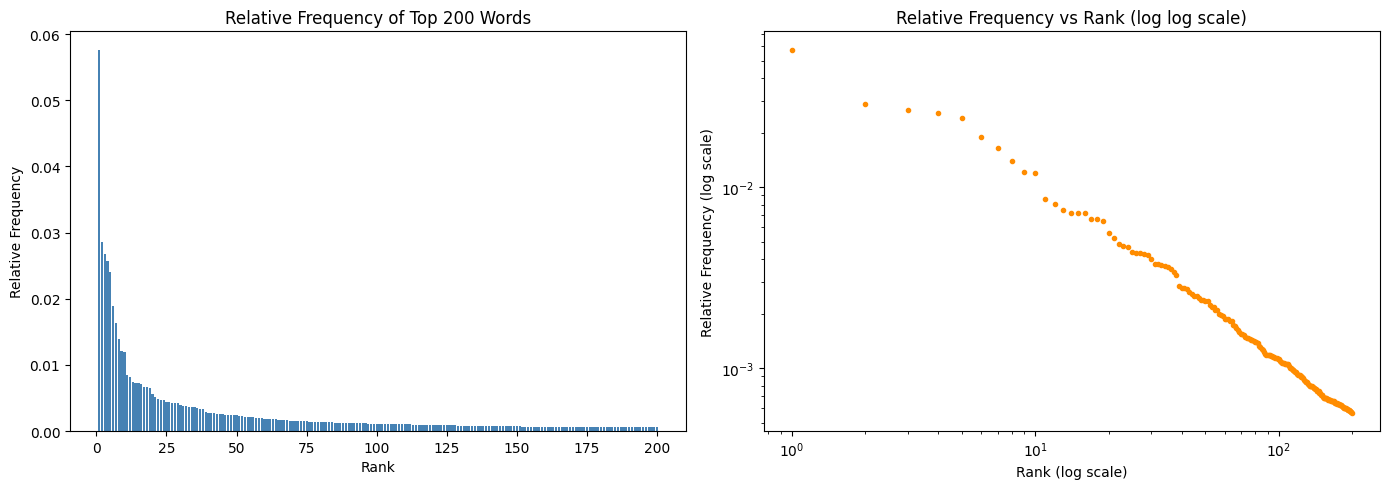

In [7]:
ranks = np.arange(1, 201)
frequencies = [count for word, count in top_200]
relative_freqs = [count / total_count for word, count in top_200]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(ranks, relative_freqs, color='steelblue')
axes[0].set_xlabel('Rank')
axes[0].set_ylabel('Relative Frequency')
axes[0].set_title('Relative Frequency of Top 200 Words')

axes[1].plot(ranks, relative_freqs, marker='o', markersize=3, linestyle='none', color='darkorange')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Rank (log scale)')
axes[1].set_ylabel('Relative Frequency (log scale)')
axes[1].set_title('Relative Frequency vs Rank (log log scale)')

plt.tight_layout()
plt.savefig('top200_frequency.png', dpi=120)
plt.show()

## 6. Does this follow Zipf's law?

Zipf's law states that the frequency of a word is approximately proportional to one divided by its rank. In other words, the most common term should appear around twice as often as the second most common word, three times as often as the third most common word, and so on. On a log-log plot, the relationship appears as a relatively straight line.

To test this, the actual relative frequency of the top 200 words is compared to what Zipf's rule predicts, with the frequency of the most common word as the starting point.

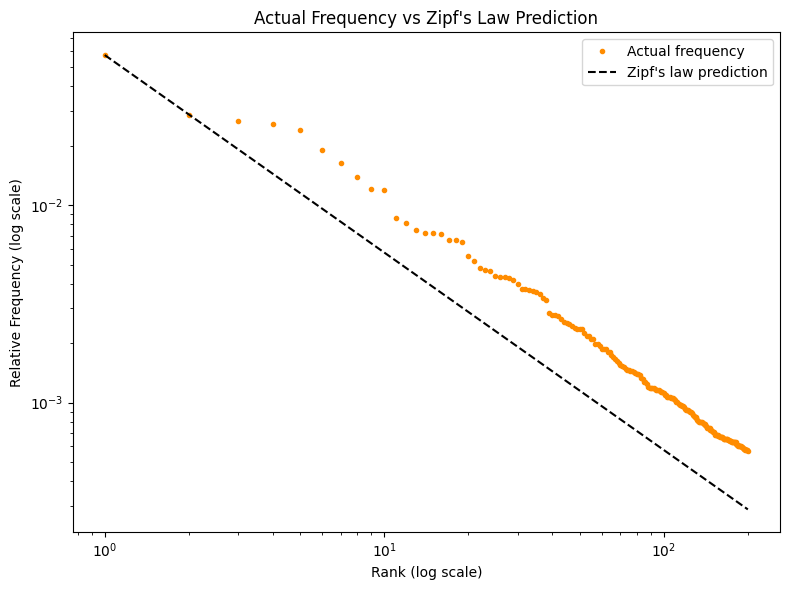

In [8]:
most_common_freq = relative_freqs[0]
zipf_prediction = [most_common_freq / r for r in ranks]

plt.figure(figsize=(8, 6))
plt.plot(ranks, relative_freqs, marker='o', markersize=3, linestyle='none', label='Actual frequency', color='darkorange')
plt.plot(ranks, zipf_prediction, linestyle='--', label="Zipf's law prediction", color='black')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Rank (log scale)')
plt.ylabel('Relative Frequency (log scale)')
plt.title("Actual Frequency vs Zipf's Law Prediction")
plt.legend()
plt.tight_layout()
plt.savefig('zipf_comparison.png', dpi=120)
plt.show()

The graph shows that the actual word frequencies generally follow Zipf’s Law, especially in the overall downward trend from high-ranked words to lower-ranked words. On the log-log plot, the points form a mostly straight declining pattern, which is consistent with Zipf’s Law. However, the actual frequencies do not perfectly match the predicted Zipf line. After the first few words, many actual frequencies are slightly higher than the simple Zipf prediction, meaning the frequency distribution declines somewhat more slowly than the ideal rule. Overall, Zipf’s Law provides a useful approximation for this corpus, but the movie reviews corpus does not follow it perfectly.

## 7. How might this corpus differ from all words in all corpora?

Movie reviews are a fairly narrow type of writing, so some differences from a general sample of all text would be expected.

First, since these are opinion pieces, words tied to evaluation and judgment, like "good," "bad," "great," "boring," and "terrible," probably show up more often than they would in a totally general text sample, where descriptive and narrative words might take up more space.

Second, movie reviews talk about a specific set of nouns over and over, things like film, movie, character, plot, director, and actor. These words would be rare in a general corpus but are common here because of the subject matter.

Third, movie reviews are written in a casual, conversational style. Common contractions and informal phrasing might appear more often than in a corpus built from formal writing like news articles or academic papers.

Even with these differences, the very top of the list looks almost identical to what would be expected in general English. Words like "the," "a," "and," "of," and "to" dominate no matter what kind of text is being looked at. This makes sense, since these are function words that hold sentences together and get used constantly regardless of topic. The differences between this corpus and "all words in all corpora" would mostly show up further down the frequency list, where topic-specific words start to take over from generic function words.

## Conclusion

This assignment examined high-frequency words in the NLTK Movie Reviews corpus. After cleaning the corpus by lowercasing words and removing non-alphabetic tokens, the corpus contained 1,329,753 alphabetic word occurrences and 38,889 unique words. The analysis showed that only 111 unique words accounted for half of all word occurrences, demonstrating that word usage is highly concentrated among a small group of common words.

The 200 most frequent words were identified and their relative frequencies were visualized. The frequency distribution generally followed the pattern expected under Zipf’s Law, where a small number of words occur very frequently and many words occur much less often. However, the distribution was not a perfect match, which is expected because this corpus is limited to movie reviews rather than representing all types of written language.

Overall, the results show that the Movie Reviews corpus follows common language-frequency patterns while also reflecting topic-specific vocabulary related to films, opinions, characters, plots, actors, and directors.